In [ ]:
!pip -q install pyarrow

In [6]:
!pip -q install pandas openpyxl

In [8]:
!pip -q install openai

In [9]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, time
from openai import OpenAI

### Loading files

In [3]:
DATA_DIR = "/content/drive/MyDrive/AICN_generate_data"

In [9]:
collab_notes = pd.read_parquet(os.path.join(DATA_DIR, "collaborative_notes.parquet"))
suggestions_df = pd.read_parquet(os.path.join(DATA_DIR, "collab_ratings.parquet"))

In [2]:
# load & process to filter only collaborative notes

note_files = sorted(glob.glob(os.path.join(DATA_DIR, "notes*.tsv")))
print("Found note files:", note_files)

notes_list = []
for f in note_files:
    df = pd.read_csv(
        f,
        sep="\t",
        usecols=["noteId", "tweetId", "isCollaborativeNote"],
        low_memory=False
    )
    notes_list.append(df)

notes_df = pd.concat(notes_list, ignore_index=True)

collab_notes = notes_df[notes_df["isCollaborativeNote"] == 1][["noteId", "tweetId"]].drop_duplicates()

print("Total notes rows loaded:", len(notes_df))
print("Unique collaborative noteIds:", collab_notes["noteId"].nunique())

Found note files: ['/content/drive/MyDrive/AICN_generate_data/notes-00000.tsv', '/content/drive/MyDrive/AICN_generate_data/notes-00001.tsv']
Total notes rows loaded: 2441213
Unique collaborative noteIds: 5865


In [6]:
collab_notes.head()

,noteId,tweetId
2435348,2021411467829051490,1300931249947672576
2435349,2023532126180876533,1644068292389228550
2435350,2024855965028553026,1670899448086446080
2435351,2019853905044086819,1707716388603781398
2435352,2021044437527249321,1717420732949430698


In [5]:
# save the processed notes
out_path = os.path.join(DATA_DIR, "collaborative_notes.parquet")
collab_notes.to_parquet(out_path, index=False)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/AICN_generate_data/collaborative_notes.parquet


In [5]:
# get ratings with rater id, created time, and the suggest content
rating_files = sorted(glob.glob(os.path.join(DATA_DIR, "ratings*.tsv")))
print("Found note files:", rating_files)

ratings = []
usecols = ["noteId", "raterParticipantId", "createdAtMillis", "suggestion"]  # keep minimal columns for speed

for f in rating_files:
    df = pd.read_csv(f, sep="\t", usecols=lambda c: c in usecols, low_memory=False)
    ratings.append(df)

ratings_df = pd.concat(ratings, ignore_index=True)

# Keep suggestion rows only (non-null and non-empty after strip)
ratings_df["suggestion"] = ratings_df["suggestion"].astype("string")
suggestions_df = ratings_df[ratings_df["suggestion"].notna() & (ratings_df["suggestion"].str.strip() != "")].copy()
suggestions_df["ratingCreatedAt"] = pd.to_datetime(suggestions_df["createdAtMillis"], unit="ms", utc=True)

print("Total ratings rows:", len(ratings_df))
print("Suggestion rows:", len(suggestions_df))
print("Unique noteIds with suggestions:", suggestions_df["noteId"].nunique())

Found note files: ['/content/drive/MyDrive/AICN_generate_data/ratings-00000.tsv', '/content/drive/MyDrive/AICN_generate_data/ratings-00001.tsv', '/content/drive/MyDrive/AICN_generate_data/ratings-00002.tsv', '/content/drive/MyDrive/AICN_generate_data/ratings-00003.tsv', '/content/drive/MyDrive/AICN_generate_data/ratings-00004.tsv', '/content/drive/MyDrive/AICN_generate_data/ratings-00005.tsv', '/content/drive/MyDrive/AICN_generate_data/ratings-00006.tsv']
Total ratings rows: 201428502
Suggestion rows: 2810
Unique noteIds with suggestions: 2414


In [6]:
suggestions_df.head()

,noteId,raterParticipantId,createdAtMillis,suggestion,ratingCreatedAt
22642943,2014117943958012199,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769128077708,please elaborate more on &quot;appears to be a...,2026-01-23 00:27:57.708000+00:00
22644234,2014121093532098991,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769117393958,"good note, good job 👍",2026-01-22 21:29:53.958000+00:00
22875063,2014450474209182195,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769121328744,Can you add more reliable sources? Thanks.,2026-01-22 22:35:28.744000+00:00
22887096,2014466977717485974,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769128425651,please explain more details around &quot;metap...,2026-01-23 00:33:45.651000+00:00
22919174,2014495172550406429,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769180881772,"Note is needed, post is obviously misleading",2026-01-23 15:08:01.772000+00:00


In [7]:
# save the processed ratings
out_path = os.path.join(DATA_DIR, "collab_ratings.parquet")
suggestions_df.to_parquet(out_path, index=False)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/AICN_generate_data/collab_ratings.parquet


In [10]:
# Inner join ensures we only analyze suggestions attached to collaborative notes
collab_suggestions = suggestions_df.merge(collab_notes, on="noteId", how="inner")
print("Suggestion rows on collaborative notes:", len(collab_suggestions))
print("Unique collaborative notes with suggestions:", collab_suggestions["noteId"].nunique())

Suggestion rows on collaborative notes: 2809
Unique collaborative notes with suggestions: 2413


In [11]:
collab_suggestions.head(2)

,noteId,raterParticipantId,createdAtMillis,suggestion,ratingCreatedAt,tweetId
0,2014117943958012199,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769128077708,please elaborate more on &quot;appears to be a...,2026-01-23 00:27:57.708000+00:00,-1
1,2014121093532098991,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769117393958,"good note, good job 👍",2026-01-22 21:29:53.958000+00:00,-1


# Step 2 Dava Visualization

### How many suggestions per unique collaborative note?

In [ ]:
suggestions_per_note = (
    collab_suggestions.groupby("noteId")
    .size()
    .rename("numSuggestions")
    .reset_index()
)

suggestions_per_note["numSuggestions"].describe()

,numSuggestions
count,2413.000000
mean,1.164111
std,0.648705
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,13.000000


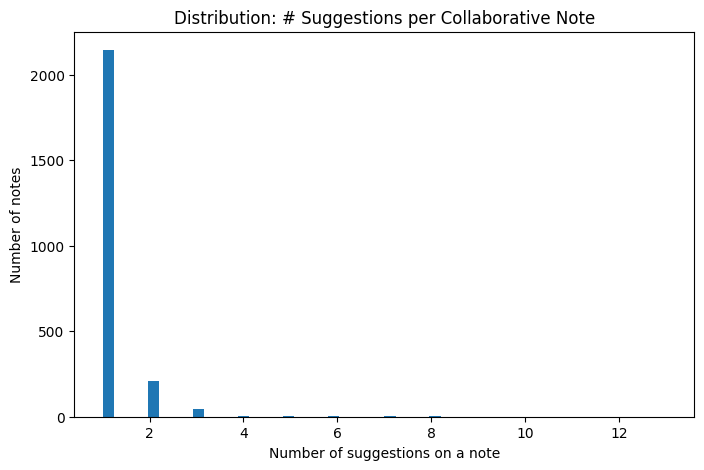

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(suggestions_per_note["numSuggestions"], bins=50)
plt.title("Distribution: # Suggestions per Collaborative Note")
plt.xlabel("Number of suggestions on a note")
plt.ylabel("Number of notes")
plt.show()


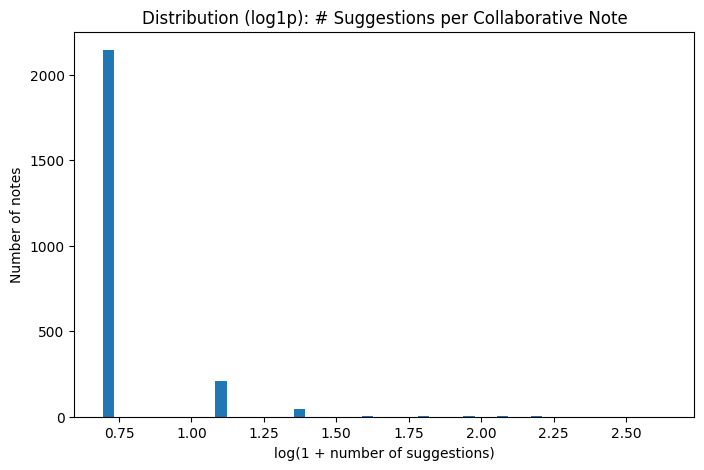

In [ ]:

# Optional: log-scale x if it’s heavy-tailed
plt.figure(figsize=(8,5))
plt.hist(np.log1p(suggestions_per_note["numSuggestions"]), bins=50)
plt.title("Distribution (log1p): # Suggestions per Collaborative Note")
plt.xlabel("log(1 + number of suggestions)")
plt.ylabel("Number of notes")
plt.show()

### How many people do these suggestions come from?” + “Are we bringing in more people?

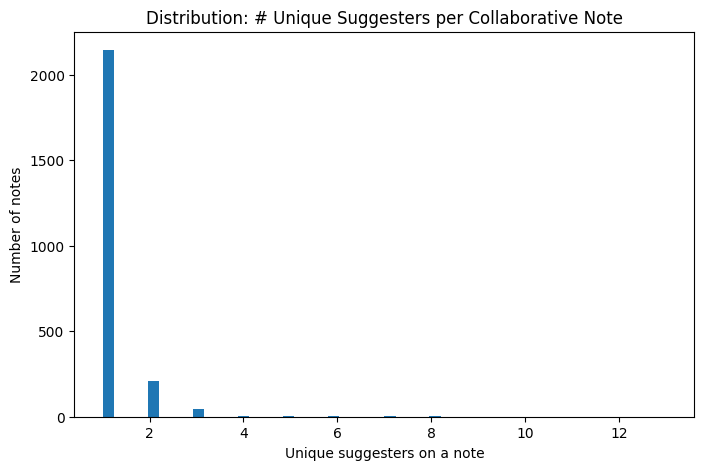

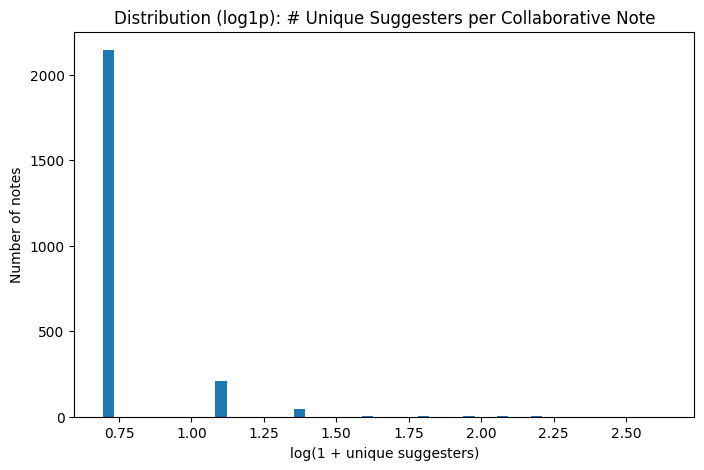

In [ ]:


unique_suggesters_per_note = (
    collab_suggestions.groupby("noteId")["raterParticipantId"]
    .nunique()
    .rename("numUniqueSuggesters")
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.hist(unique_suggesters_per_note["numUniqueSuggesters"], bins=50)
plt.title("Distribution: # Unique Suggesters per Collaborative Note")
plt.xlabel("Unique suggesters on a note")
plt.ylabel("Number of notes")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(np.log1p(unique_suggesters_per_note["numUniqueSuggesters"]), bins=50)
plt.title("Distribution (log1p): # Unique Suggesters per Collaborative Note")
plt.xlabel("log(1 + unique suggesters)")
plt.ylabel("Number of notes")
plt.show()

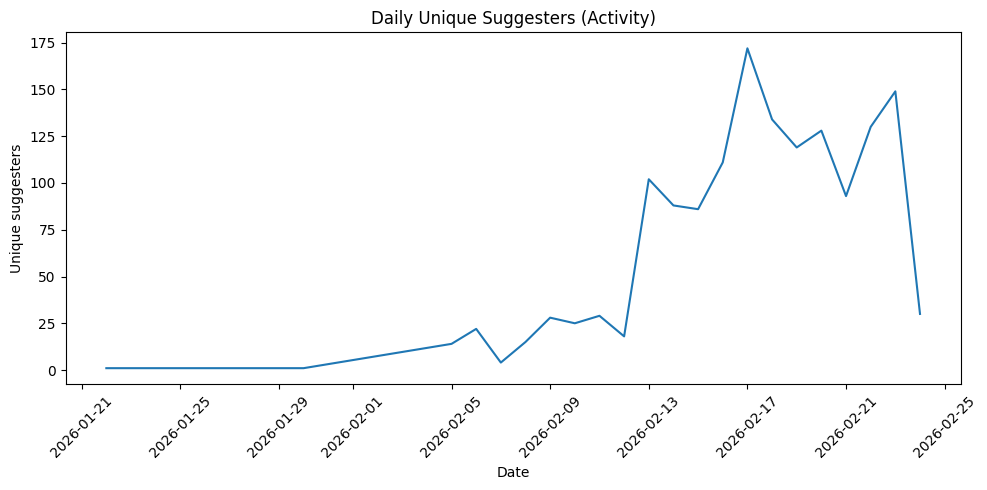

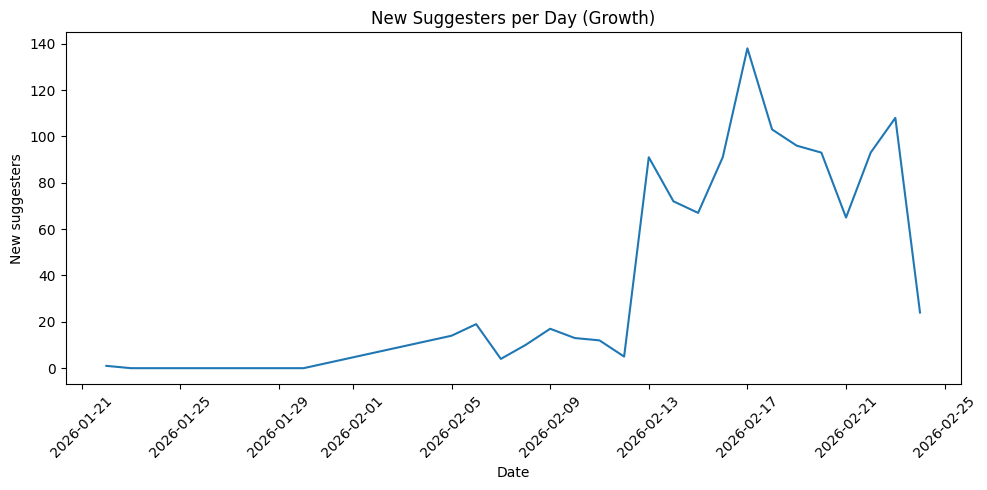

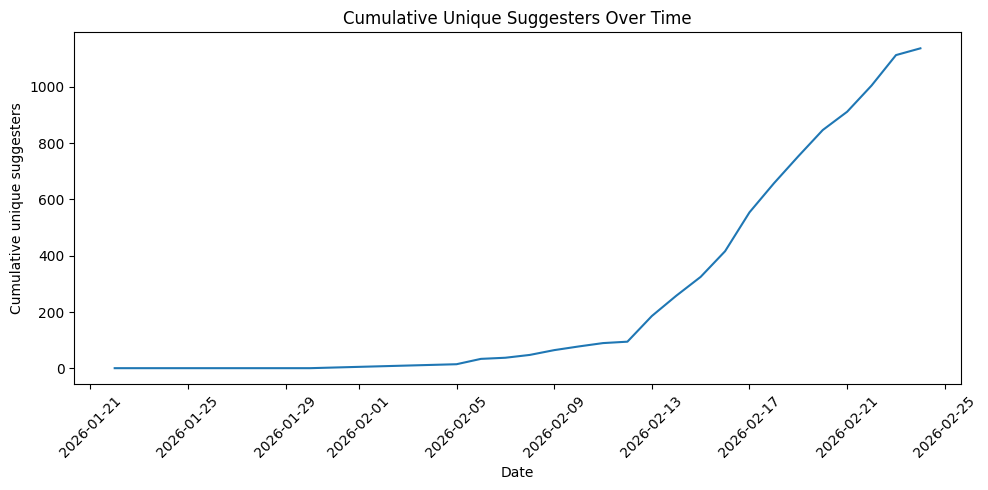

In [ ]:
collab_suggestions["date"] = collab_suggestions["ratingCreatedAt"].dt.date

daily_unique = (
    collab_suggestions.groupby("date")["raterParticipantId"]
    .nunique()
    .reset_index(name="dailyUniqueSuggesters")
    .sort_values("date")
)

first_seen = (
    collab_suggestions.groupby("raterParticipantId")["date"]
    .min()
    .reset_index(name="firstDate")
)

new_suggesters = (
    first_seen.groupby("firstDate")["raterParticipantId"]
    .nunique()
    .reset_index(name="newSuggesters")
    .rename(columns={"firstDate": "date"})
    .sort_values("date")
)

trend = daily_unique.merge(new_suggesters, on="date", how="left")
trend["newSuggesters"] = trend["newSuggesters"].fillna(0).astype(int)
trend["cumulativeUniqueSuggesters"] = trend["newSuggesters"].cumsum()

plt.figure(figsize=(10,5))
plt.plot(trend["date"], trend["dailyUniqueSuggesters"])
plt.title("Daily Unique Suggesters (Activity)")
plt.xlabel("Date"); plt.ylabel("Unique suggesters")
plt.xticks(rotation=45); plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(trend["date"], trend["newSuggesters"])
plt.title("New Suggesters per Day (Growth)")
plt.xlabel("Date"); plt.ylabel("New suggesters")
plt.xticks(rotation=45); plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(trend["date"], trend["cumulativeUniqueSuggesters"])
plt.title("Cumulative Unique Suggesters Over Time")
plt.xlabel("Date"); plt.ylabel("Cumulative unique suggesters")
plt.xticks(rotation=45); plt.tight_layout()
plt.show()

## Step 3

In [12]:
# Keep only required columns
sample_base = collab_suggestions[["tweetId", "noteId", "suggestion"]].dropna()

print(len(sample_base))
sample_base.head(5)

2809


,tweetId,noteId,suggestion
0,-1,2014117943958012199,please elaborate more on &quot;appears to be a...
1,-1,2014121093532098991,"good note, good job 👍"
2,-1,2014466977717485974,please explain more details around &quot;metap...
3,-1,2014495172550406429,"Note is needed, post is obviously misleading"
4,-1,2014496979053879586,"This should be a misleading post, context needed"


In [13]:
print("Rows eligible for sampling:", len(sample_base))
sample_notes = sample_base["noteId"].unique()
sample_100 = sample_base.sample(n=100, random_state=42).reset_index(drop=True)

sample_100.head(5)

Rows eligible for sampling: 2809


,tweetId,noteId,suggestion
0,2023161539897720931,2023752737398145264,Opinion should be in the comments
1,2025303478013166046,2025314997350662624,This is more of a comment than anything becaus...
2,2025303478013166046,2025331532362383443,NO AI community notes!!!
3,2023659458896031834,2023670307718836244,The eclipse will not be visible during the nig...
4,2022801777570070899,2022944716422349206,Sprites occur above thunder storms.You provide...


In [14]:
out_xlsx = os.path.join(DATA_DIR, "sample_100_suggestions.xlsx")
sample_100.to_excel(out_xlsx, index=False)
print("Saved:", out_xlsx)

Saved: /content/drive/MyDrive/AICN_generate_data/sample_100_suggestions.xlsx


# Step 4 LLM prompt for auto-annotation

In [22]:
classification_prompt = """
You are a researcher analyzing Twitter Community Notes suggestions.

Input:
You will receive rows. Each row has:
- tweetId (String)
- noteId (String)
- suggestion (String)

Task:
For EACH suggestion text, assign exactly ONE label in each of 3 dimensions:
(1) SuggestionIntent
(2) EvidenceLevel
(3) Actionability

Dimension 1: SuggestionIntent (choose ONE)
- FACTUAL_CORRECTION: corrects a specific factual claim (states something is wrong/false or provides a corrected fact).
- ADD_CONTEXT: adds missing context/nuance without necessarily claiming the note is false; clarifies attribution, timeline, definitions, exceptions.
- CHALLENGE_LOGIC: critiques reasoning/inference (e.g., "doesn't prove", correlation vs causation).
- SOURCE_CRITIQUE: critiques the quality/appropriateness of sources (e.g., "Wikipedia is not reliable", "needs better sources").
- META_POLICY_CN: comments on Community Notes policy/process rather than the tweet content (e.g., "this belongs in replies", "no AI notes").
- VALUE_JUDGMENT: moral/political judgment, insults, or labeling people/groups without factual guidance.
- FORMATTING_EDIT: copyediting or writing/structure changes to the note itself (clarity, wording, grammar, what to mention).

Tie-breakers for SuggestionIntent:
- If it says "X is wrong/false/incorrect" or clearly provides a corrected fact → FACTUAL_CORRECTION.
- If it says "add/mention/clarify" to improve completeness → ADD_CONTEXT (unless it is purely copyediting, then FORMATTING_EDIT).
- If it criticizes sources → SOURCE_CRITIQUE even if it also suggests adding sources.
- If it’s about CN policy or where the note should go → META_POLICY_CN.

Dimension 2: EvidenceLevel (choose ONE)
- HAS_LINKS: includes URLs (http/https/www).
- VERIFIABLE_NO_LINK: no URLs, but contains a specific checkable claim (names, places, dates, numbers, identifiers).
- SOURCE_QUALITY_COMMENT: talks about source quality or need for citations (e.g., "unreliable source", "needs citations") without providing sources.
- PURE_ASSERTION: opinion/reaction with no checkable details.

Dimension 3: Actionability (choose ONE)
- HIGH: concrete instruction that can be directly applied to rewrite the note (specific add/remove/replace wording or specific corrected fact).
- MEDIUM: general but usable guidance (what to address, what kind of context is missing) without exact wording.
- LOW: reaction, insult, or non-instruction; not usable to edit the note.


Rules:
- Use ONLY the text of the suggestion. Do not assume external facts.
- IMPORTANT: tweetId and noteId must be returned EXACTLY as given (do not reformat, truncate, or convert to scientific notation).

Output format (STRICT):
Return ONLY valid JSON in exactly this shape:
{
  "rows": [
    {
      "tweetId": "...",
      "noteId": "...",
      "suggestion": "...",
      "SuggestionIntent": "...",
      "EvidenceLevel": "...",
      "Actionability": "..."
    }
  ]
}
Do not output any additional text.
"""

In [7]:
sample = pd.read_excel(os.path.join("/content/drive/MyDrive/AICN_generate_data/sample_100_suggestions.xlsx"))
sample.head(3)

,tweetId,noteId,suggestion
0,2023161539897721088,2023752737398145024,Opinion should be in the comments
1,2025303478013166080,2025314997350662912,This is more of a comment than anything becaus...
2,2025303478013166080,2025331532362383104,NO AI community notes!!!


In [10]:

client = OpenAI()

In [23]:
import json, re
import pandas as pd
from openai import RateLimitError, APIError, BadRequestError, AuthenticationError

def extract_json_object(text: str):
    """Extract the first top-level JSON object from a string."""
    text = text.strip()
    if not text:
        raise ValueError("Empty model output")
    # Try direct parse first
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    # Fallback: find {...} block
    m = re.search(r"\{.*\}", text, flags=re.S)
    if not m:
        raise ValueError(f"No JSON object found. Raw output starts with: {text[:200]!r}")
    return json.loads(m.group(0))

def annotate_batch(batch_df, model="gpt-4o-mini", debug=True):
    payload = batch_df[["tweetId","noteId","suggestion"]].to_dict(orient="records")

    try:
        resp = client.responses.create(
            model=model,
            input=[
                {"role": "system", "content": classification_prompt},
                {"role": "user", "content": json.dumps({"rows": payload}, ensure_ascii=False)}
            ],
        )
    except RateLimitError as e:
        # This includes insufficient_quota
        raise RuntimeError(f"OpenAI API RateLimitError/Quota issue: {e}") from e
    except (AuthenticationError, BadRequestError, APIError) as e:
        raise RuntimeError(f"OpenAI API call failed: {e}") from e

    raw = (resp.output_text or "").strip()

    if debug:
        print("=== RAW OUTPUT (first 500 chars) ===")
        print(raw[:500] if raw else "<EMPTY>")
        print("=== END RAW OUTPUT ===")

    data = extract_json_object(raw)

    # Your prompt says “each element”, but you’re sending {"rows":[...]}.
    # So we support either:
    # A) {"rows":[{...},{...}]}
    # B) [{...},{...}]  (array only)
    if isinstance(data, dict) and "rows" in data:
        rows = data["rows"]
    elif isinstance(data, list):
        rows = data
    else:
        raise ValueError(f"Unexpected JSON shape: {type(data)} keys={list(data.keys()) if isinstance(data, dict) else ''}")

    return pd.DataFrame(rows)

In [11]:
response_schema = {
  "name": "suggestion_labels",
  "strict": True,
  "schema": {
    "type": "object",
    "additionalProperties": False,
    "properties": {
      "rows": {
        "type": "array",
        "items": {
          "type": "object",
          "additionalProperties": False,
          "properties": {
            "tweetId": {"type": "string"},
            "noteId": {"type": "string"},
            "suggestion": {"type": "string"},
            "SuggestionIntent": {
              "type": "string",
              "enum": ["FACTUAL_CORRECTION","ADD_CONTEXT","CHALLENGE_LOGIC","SOURCE_CRITIQUE","META_POLICY_CN","VALUE_JUDGMENT","FORMATTING_EDIT"]
            },
            "EvidenceLevel": {
              "type": "string",
              "enum": ["HAS_LINKS","VERIFIABLE_NO_LINK","SOURCE_QUALITY_COMMENT","PURE_ASSERTION"]
            },
            "Actionability": {"type": "string", "enum": ["HIGH","MEDIUM","LOW"]}
          },
          "required": ["tweetId","noteId","suggestion","SuggestionIntent","EvidenceLevel","Actionability"]
        }
      }
    },
    "required": ["rows"]
  }
}

In [25]:
def annotate_batch(batch_df, model="gpt-4o-mini"):
    payload = batch_df[["tweetId","noteId","suggestion"]].to_dict(orient="records")
    resp = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": classification_prompt},
            {"role": "user", "content": json.dumps({"rows": payload}, ensure_ascii=False)}
        ],
    )
    return pd.DataFrame(json.loads(resp.output_text)["rows"])

In [14]:
import openai
print(openai.__version__)

2.24.0


In [24]:
sample20 = sample.head(20).copy()
labels20 = annotate_batch(sample20, model="gpt-4o-mini", debug=True)
labels20.head()

=== RAW OUTPUT (first 500 chars) ===
{
  "rows": [
    {
      "tweetId": 2023161539897721088,
      "noteId": 2023752737398145024,
      "suggestion": "Opinion should be in the comments ",
      "SuggestionIntent": "META_POLICY_CN",
      "EvidenceLevel": "PURE_ASSERTION",
      "Actionability": "LOW"
    },
    {
      "tweetId": 2025303478013166080,
      "noteId": 2025314997350662912,
      "suggestion": "This is more of a comment than anything because it’s simply Opinion disagreeing with the poster for picking a side.",
      
=== END RAW OUTPUT ===


,tweetId,noteId,suggestion,SuggestionIntent,EvidenceLevel,Actionability
0,2023161539897721088,2023752737398145024,Opinion should be in the comments,META_POLICY_CN,PURE_ASSERTION,LOW
1,2025303478013166080,2025314997350662912,This is more of a comment than anything becaus...,VALUE_JUDGMENT,PURE_ASSERTION,LOW
2,2025303478013166080,2025331532362383104,NO AI community notes!!!,META_POLICY_CN,PURE_ASSERTION,LOW
3,2023659458896032000,2023670307718835968,The eclipse will not be visible during the nig...,FACTUAL_CORRECTION,VERIFIABLE_NO_LINK,HIGH
4,2022801777570071040,2022944716422349056,Sprites occur above thunder storms.You provide...,SOURCE_CRITIQUE,SOURCE_QUALITY_COMMENT,MEDIUM


In [26]:

out_path = os.path.join(DATA_DIR, "labels_test_20.csv")
labels20.to_csv(out_path, index=False)